# K-Means Clustering: E-Commerce Customer Behavior

## Group C1

**Dataset:** `ecommerce_customer_behavior.csv`  
**Unit of Analysis:** Customers  
**Technique:** K-Means Clustering

### Objective

The objective of this analysis is to identify meaningful customer segments based on e-commerce customer behavior. The analysis follows a complete K-Means clustering pipeline, including exploratory data analysis, feature selection, preprocessing, determination of the optimal number of clusters, model fitting, cluster evaluation, customer profiling, robustness testing, and model persistence.

Because K-Means is an unsupervised learning algorithm, the dataset does not have a target variable. Customers will instead be grouped according to similarities in their behavioral characteristics.

## 1. Setup, Data Loading and Exploratory Data Analysis

This section prepares the working environment, loads the e-commerce customer behavior dataset, examines its structure and quality, and performs exploratory data analysis before clustering.

The customer identifier will be identified during data inspection and excluded from all descriptive statistics, correlations, and visualizations because an identifier uniquely labels a customer but does not represent customer behavior. Including it could introduce meaningless numerical patterns into the analysis.

### 1.1 Import Required Libraries

The following libraries are imported for data manipulation, visualization, preprocessing, clustering, model evaluation, and model persistence.

In [84]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Clustering
from sklearn.cluster import KMeans

# Cluster evaluation
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

# Model persistence
import joblib

# Display settings
pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


In [85]:
df = pd.read_csv("../data/ecommerce_customer_behavior.csv")

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [86]:
print("Dataset shape:", df.shape)
print("Number of customers:", df.shape[0])
print("Number of columns:", df.shape[1])

Dataset shape: (750, 7)
Number of customers: 750
Number of columns: 7


In [87]:
df.head()

,customer_id,preferred_device,recency_days,frequency_per_year,avg_order_value_kes,total_lifetime_spend_kes,num_categories_purchased
0,1,Desktop,290.0,0.4,2463.0,1821.0,2.0
1,2,Mobile,289.0,2.2,2704.0,10655.0,1.0
2,3,Mobile,19.0,20.2,8491.0,318415.0,4.0
3,4,Mobile,27.0,14.3,5629.0,242350.0,5.0
4,5,Mobile,101.0,10.3,6443.0,110436.0,4.0


In [88]:
print("Column names:")
for column in df.columns:
    print("-", column)

Column names:
- customer_id
- preferred_device
- recency_days
- frequency_per_year
- avg_order_value_kes
- total_lifetime_spend_kes
- num_categories_purchased


In [89]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750 entries, 0 to 749
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               750 non-null    int64  
 1   preferred_device          750 non-null    object 
 2   recency_days              750 non-null    float64
 3   frequency_per_year        750 non-null    float64
 4   avg_order_value_kes       724 non-null    float64
 5   total_lifetime_spend_kes  750 non-null    float64
 6   num_categories_purchased  750 non-null    float64
dtypes: float64(5), int64(1), object(1)
memory usage: 41.1+ KB


In [90]:
df.isnull().sum()

customer_id                  0
preferred_device             0
recency_days                 0
frequency_per_year           0
avg_order_value_kes         26
total_lifetime_spend_kes     0
num_categories_purchased     0
dtype: int64

### 1.4 Identifier and Feature Identification

The `customer_id` column is a unique identifier for each customer. Although it is stored as an integer, it does not measure customer behavior and therefore has no meaningful numerical relationship with the other variables. It is excluded from all descriptive statistics, correlations, visualizations, and the K-Means distance calculation.

The `preferred_device` variable is categorical and describes whether a customer prefers Mobile or Desktop. It will not be included directly in the K-Means distance calculation because K-Means operates on numerical distances. Instead, it can later be used for post-hoc cluster profiling to determine whether device preference differs across the identified customer segments.

The remaining five numerical variables represent customer purchasing behavior and will be examined as potential clustering features:

- `recency_days` — number of days since the customer's most recent purchase.
- `frequency_per_year` — customer's purchasing frequency per year.
- `avg_order_value_kes` — average value of a customer's orders in Kenyan shillings.
- `total_lifetime_spend_kes` — total amount spent by the customer over their lifetime.
- `num_categories_purchased` — number of product categories purchased by the customer.

In [91]:
# Exclude the customer identifier from all EDA statistics and plots
eda_df = df.drop(columns=["customer_id"])

# Numerical behavioral features
numeric_features = [
    "recency_days",
    "frequency_per_year",
    "avg_order_value_kes",
    "total_lifetime_spend_kes",
    "num_categories_purchased"
]

# Categorical feature reserved for later cluster profiling
categorical_features = ["preferred_device"]

print("Identifier excluded: customer_id")
print("\nNumerical behavioral features:")
print(numeric_features)

print("\nCategorical profiling feature:")
print(categorical_features)

Identifier excluded: customer_id

Numerical behavioral features:
['recency_days', 'frequency_per_year', 'avg_order_value_kes', 'total_lifetime_spend_kes', 'num_categories_purchased']

Categorical profiling feature:
['preferred_device']


In [92]:
eda_df.head()

,preferred_device,recency_days,frequency_per_year,avg_order_value_kes,total_lifetime_spend_kes,num_categories_purchased
0,Desktop,290.0,0.4,2463.0,1821.0,2.0
1,Mobile,289.0,2.2,2704.0,10655.0,1.0
2,Mobile,19.0,20.2,8491.0,318415.0,4.0
3,Mobile,27.0,14.3,5629.0,242350.0,5.0
4,Mobile,101.0,10.3,6443.0,110436.0,4.0


### 1.5 Descriptive Statistics

Descriptive statistics are calculated only for the numerical customer-behavior variables. The `customer_id` identifier is deliberately excluded because its numerical values are labels rather than meaningful customer characteristics.

These statistics help us understand the central tendency, spread, and range of the behavioral variables before applying K-Means clustering.

In [93]:
# Descriptive statistics for behavioral features only
descriptive_stats = eda_df[numeric_features].describe().T

descriptive_stats

,count,mean,std,min,25%,50%,75%,max
recency_days,750.0,104.142667,117.078670,1.0,15.0,30.00,173.750,394.0
frequency_per_year,750.0,10.112667,8.739543,0.2,1.8,9.65,16.275,32.0
avg_order_value_kes,724.0,5088.817680,2090.012680,1567.0,3567.5,4794.00,6287.000,10807.0
total_lifetime_spend_kes,750.0,165700.740000,188450.009592,1000.0,15524.5,115258.50,237703.000,858138.0
num_categories_purchased,750.0,3.141333,1.803060,1.0,2.0,3.00,4.000,9.0


In [94]:
# Median values of the behavioral features
eda_df[numeric_features].median()

recency_days                    30.00
frequency_per_year               9.65
avg_order_value_kes           4794.00
total_lifetime_spend_kes    115258.50
num_categories_purchased         3.00
dtype: float64

#### Descriptive Statistics Insights

The descriptive statistics reveal substantial variation in customer purchasing behavior. The median recency is **30 days**, while the mean is much higher at approximately **104 days**, suggesting that the recency distribution is right-skewed. Many customers purchased relatively recently, while a smaller group has gone much longer without making a purchase.

Customers make a median of **9.65 purchases per year**, with frequency ranging from **0.2 to 32 purchases per year**. This wide range indicates that the dataset contains both infrequent and highly active customers.

The average order value has a median of **KES 4,794** and a mean of approximately **KES 5,089**, indicating some variation in how much customers typically spend per order. The count of **724 instead of 750** also confirms that this variable contains missing observations that will require further investigation before clustering.

Total lifetime spend shows particularly large variation, ranging from **KES 1,000 to KES 858,138**. Its mean of approximately **KES 165,701** is considerably higher than its median of approximately **KES 115,259**, suggesting a right-skewed distribution in which a smaller number of high-value customers have substantially greater lifetime spending.

Customers purchase from a median of **3 product categories**, although the number ranges from **1 to 9 categories**. This suggests differences in the breadth of customer purchasing behavior, from customers focused on a single category to those purchasing across many categories.

Overall, the large differences in the ranges and units of these variables indicate that feature scaling will be necessary before K-Means clustering so that high-magnitude variables such as lifetime spending do not dominate the distance calculation.

### 1.6 Missing Value Analysis

Missing values are examined before clustering because K-Means cannot operate directly on observations containing missing numerical values. The amount and pattern of missingness will be assessed before deciding on an appropriate treatment.

In [95]:
# Missing-value count and percentage
missing_summary = pd.DataFrame({
    "Missing Count": eda_df.isnull().sum(),
    "Missing Percentage (%)": (eda_df.isnull().mean() * 100).round(2)
})

missing_summary

,Missing Count,Missing Percentage (%)
preferred_device,0,0.00
recency_days,0,0.00
frequency_per_year,0,0.00
avg_order_value_kes,26,3.47
total_lifetime_spend_kes,0,0.00
num_categories_purchased,0,0.00


In [96]:
# Separate customers with and without missing average order value
missing_aov = eda_df[eda_df["avg_order_value_kes"].isna()]
complete_aov = eda_df[eda_df["avg_order_value_kes"].notna()]

print("Customers with missing average order value:", len(missing_aov))
print("Customers with recorded average order value:", len(complete_aov))
print(
    "Percentage missing:",
    round(len(missing_aov) / len(eda_df) * 100, 2),
    "%"
)

Customers with missing average order value: 26
Customers with recorded average order value: 724
Percentage missing: 3.47 %


In [97]:
missing_aov.head(10)

,preferred_device,recency_days,frequency_per_year,avg_order_value_kes,total_lifetime_spend_kes,num_categories_purchased
10,Desktop,19.0,27.3,NaN,367896.0,6.0
81,Desktop,21.0,3.3,NaN,45928.0,1.0
117,Mobile,147.0,5.2,NaN,50145.0,4.0
167,Desktop,290.0,0.2,NaN,2113.0,2.0
290,Tablet,41.0,23.1,NaN,322732.0,4.0
298,Desktop,19.0,22.4,NaN,551909.0,4.0
300,Desktop,166.0,10.3,NaN,92357.0,4.0
302,Mobile,165.0,9.2,NaN,77484.0,2.0
383,Mobile,149.0,10.1,NaN,187980.0,4.0
454,Tablet,36.0,19.1,NaN,320835.0,4.0


In [98]:
missingness_comparison = pd.DataFrame({
    "Missing AOV": missing_aov[numeric_features].mean(),
    "Recorded AOV": complete_aov[numeric_features].mean()
})

missingness_comparison

,Missing AOV,Recorded AOV
recency_days,129.730769,103.223757
frequency_per_year,10.850000,10.086188
avg_order_value_kes,NaN,5088.817680
total_lifetime_spend_kes,187995.384615,164900.103591
num_categories_purchased,3.076923,3.143646


#### Missing Value Insight

Only `avg_order_value_kes` contains missing values, with **26 out of 750 customers (3.47%)** affected. The remaining variables have no missing observations.

Inspection of the affected customers shows that the missing average order values are **not structurally caused by an absence of purchasing activity**. Customers with missing AOV still have non-zero purchase frequencies and substantial lifetime spending. For example, some affected customers have purchase frequencies above 20 purchases per year and lifetime spending exceeding KES 300,000.

The customers with missing AOV also have broadly comparable purchasing characteristics to customers with recorded AOV. Their mean purchase frequency is **10.85 compared with 10.09**, while their mean number of categories purchased is **3.08 compared with 3.14**.

Therefore, there is no obvious structural explanation for the missing AOV values based on the observed variables. The missingness will be treated as non-structural missing data during preprocessing rather than interpreting the missing values as zero spending. An appropriate imputation method will be selected before K-Means clustering.

### 1.7 Preferred Device Distribution

`preferred_device` is examined separately as a categorical customer characteristic. It is not included in the numerical K-Means distance calculation, but it can later help profile and interpret the resulting customer clusters.

In [99]:
# Frequency distribution of preferred devices
device_counts = eda_df["preferred_device"].value_counts()

device_counts

preferred_device
Mobile     405
Desktop    283
Tablet      62
Name: count, dtype: int64

In [100]:
# Percentage distribution
device_percentages = (
    eda_df["preferred_device"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

device_percentages

preferred_device
Mobile     54.00
Desktop    37.73
Tablet      8.27
Name: proportion, dtype: float64

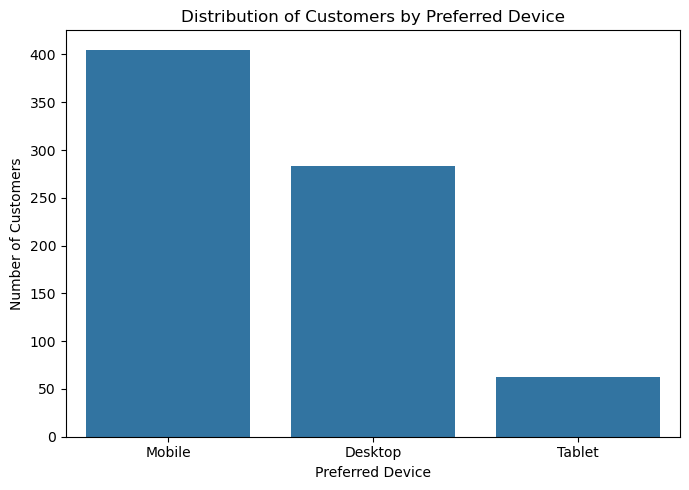

In [101]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=eda_df,
    x="preferred_device",
    order=eda_df["preferred_device"].value_counts().index
)

plt.title("Distribution of Customers by Preferred Device")
plt.xlabel("Preferred Device")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

**Insight:** Mobile is the most commonly preferred device among customers, followed by Desktop, while Tablet is used by a much smaller proportion of customers. This suggests that the customer base is predominantly mobile-oriented; however, `preferred_device` will be reserved for post-hoc cluster profiling rather than included in the K-Means distance calculation.

### 1.8 Distribution of Numerical Customer Features

The distributions of the five numerical behavioral variables are examined individually to identify skewness, spread, concentration, and potential extreme values. The `customer_id` column remains excluded because it is an identifier rather than a behavioral feature.

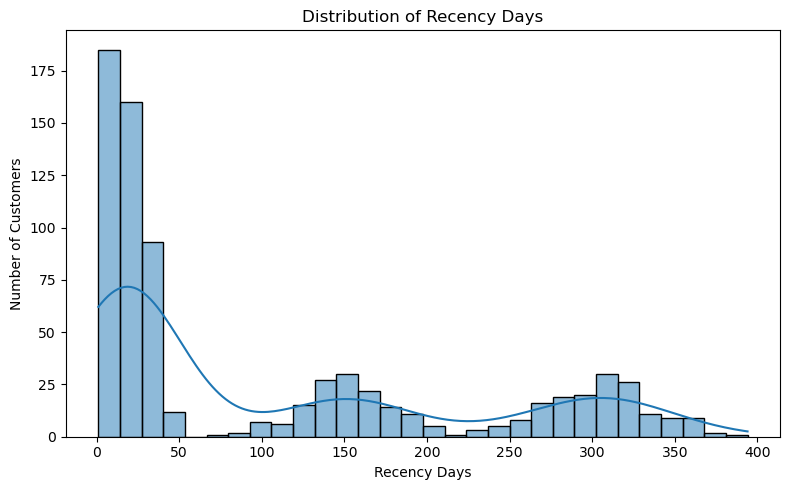

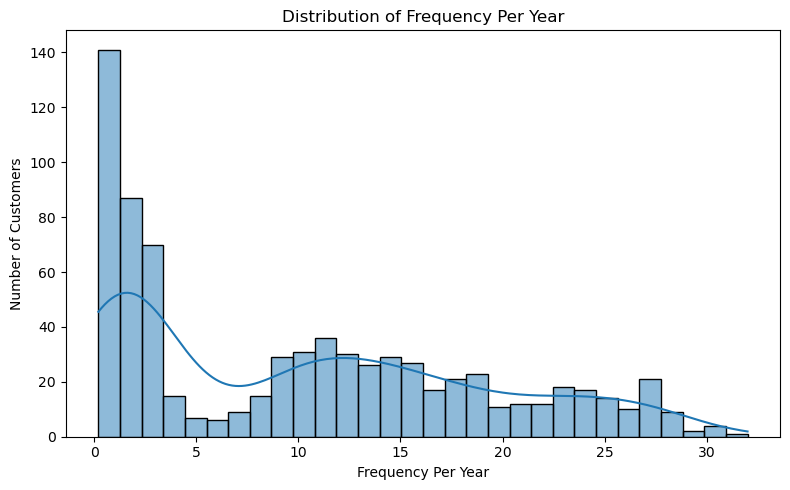

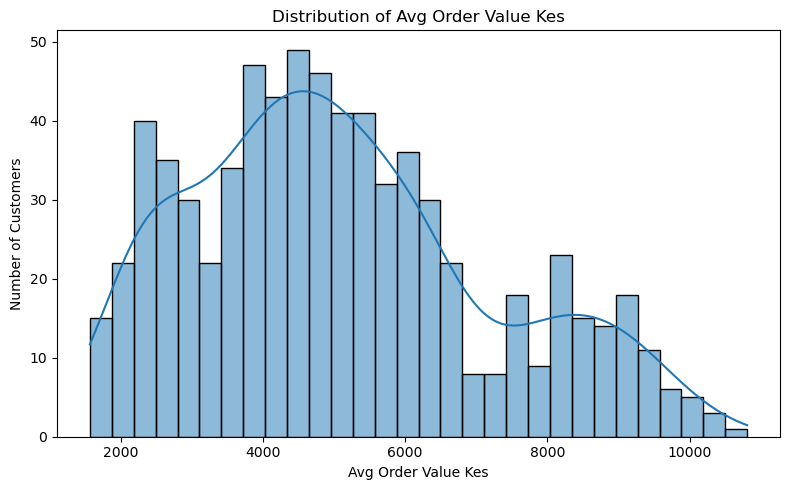

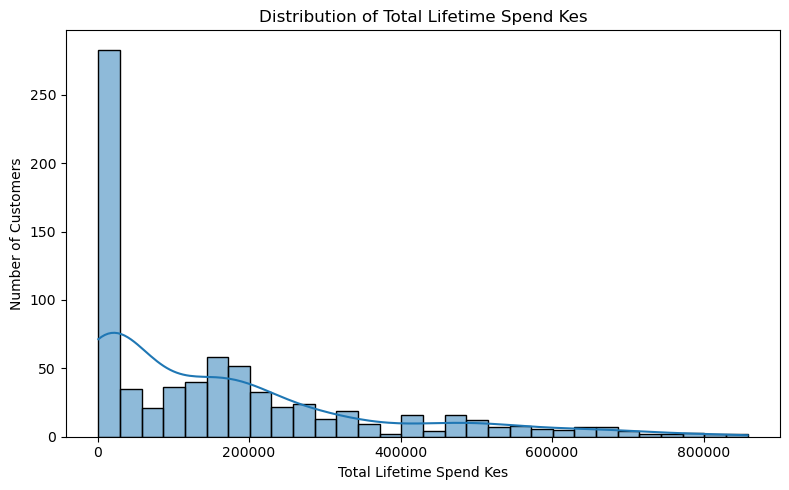

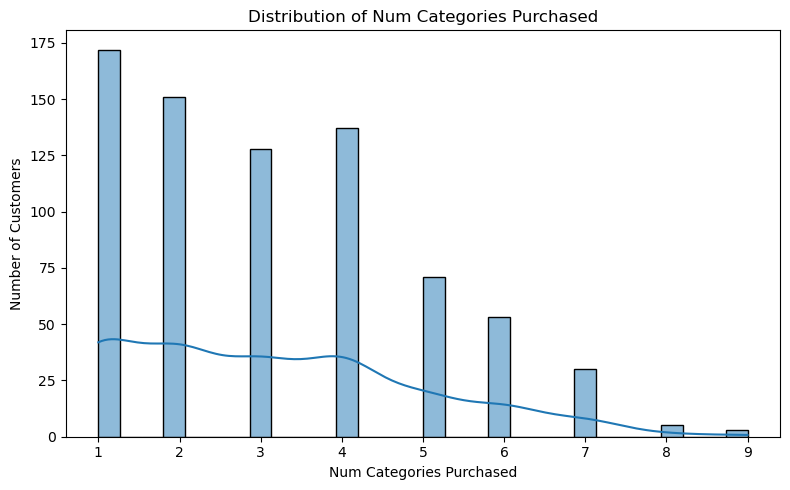

In [102]:
# Plot distributions of numerical behavioral features only
for feature in numeric_features:
    plt.figure(figsize=(8, 5))
    
    sns.histplot(
        data=eda_df,
        x=feature,
        bins=30,
        kde=True
    )
    
    plt.title(f"Distribution of {feature.replace('_', ' ').title()}")
    plt.xlabel(feature.replace("_", " ").title())
    plt.ylabel("Number of Customers")
    
    plt.tight_layout()
    plt.show()

**Insight:** `recency_days` has a distinctly non-normal and multi-peaked distribution. A large group of customers purchased very recently, particularly within roughly the first 50 days, while other groups have much longer recency values around 100–200 days and 250–350 days. This suggests that the dataset may contain customers at different levels of recent engagement.

**Insight:** `frequency_per_year` also shows a non-normal distribution, with many customers making only a few purchases per year and other groups purchasing much more frequently. The broad range from 0.2 to 32 purchases per year suggests meaningful differences in customer purchasing activity that may help distinguish customer segments.

**Insight:** `avg_order_value_kes` is spread widely across customers, with most observations concentrated around the middle of the distribution and fewer customers having very high average order values. The distribution also appears to contain more than one concentration of values, suggesting differences in customers' typical transaction sizes.

**Insight:** `total_lifetime_spend_kes` is strongly right-skewed, with many customers having relatively low lifetime spending and a smaller number reaching several hundred thousand Kenyan shillings. These high-spending customers extend the distribution to approximately KES 858,000 and may represent an important high-value customer segment rather than simply erroneous observations.

**Insight:** `num_categories_purchased` is a discrete variable concentrated between 1 and 4 categories, while relatively few customers purchase from 7 to 9 categories. This indicates that most customers have a fairly focused purchasing range, while a smaller group displays broader product-category engagement.

### 1.9 Potential Outlier Analysis

Boxplots are used to identify unusually high or low values among the numerical behavioral features. Potential outliers are not automatically removed because extreme customer behavior may represent genuine and commercially meaningful customer segments. Their presence is first examined before any preprocessing decision is made.

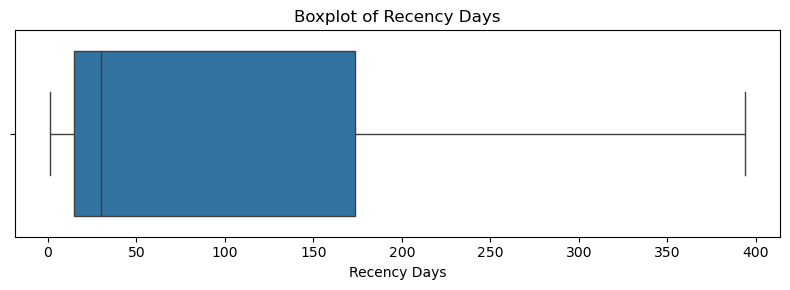

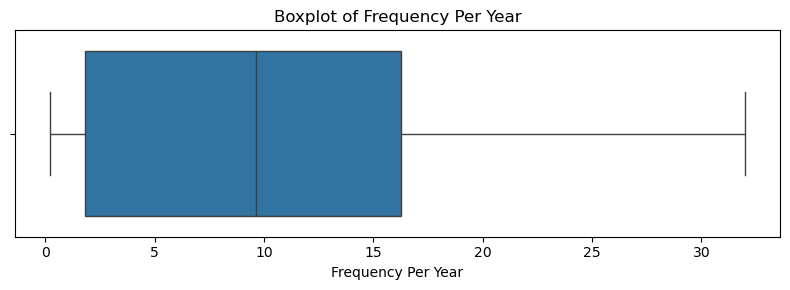

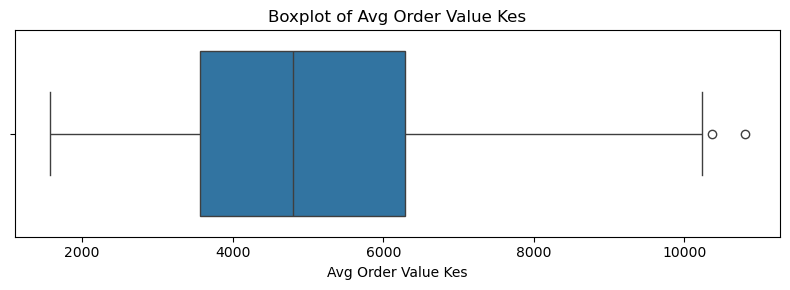

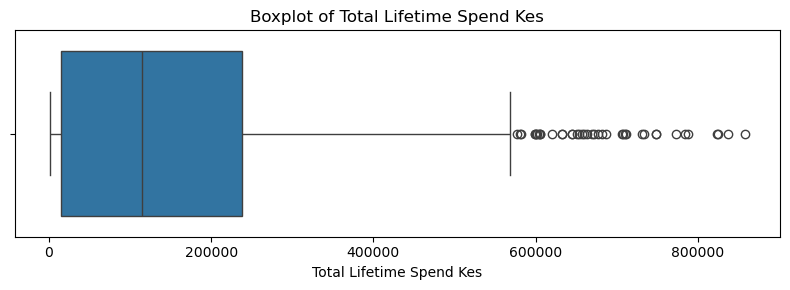

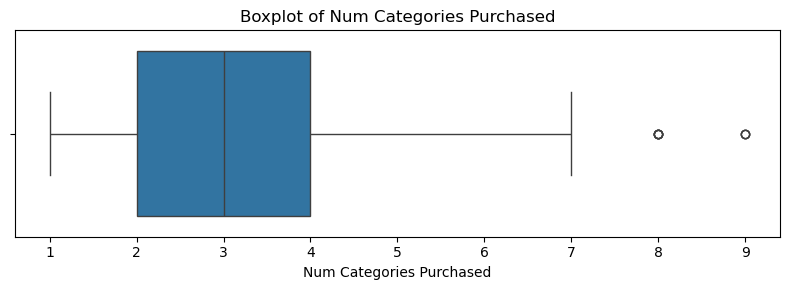

In [103]:
for feature in numeric_features:
    plt.figure(figsize=(8, 3))
    
    sns.boxplot(
        data=eda_df,
        x=feature
    )
    
    plt.title(f"Boxplot of {feature.replace('_', ' ').title()}")
    plt.xlabel(feature.replace("_", " ").title())
    
    plt.tight_layout()
    plt.show()

**Insight:** The boxplot for `recency_days` shows a wide spread in customer recency but no observations flagged as outliers by the boxplot rule. The long upper whisker reflects customers who have not purchased for a long period and should be retained because they may represent inactive or disengaged customer segments.

**Insight:** `frequency_per_year` does not show observations flagged as outliers by the boxplot rule. The wide range reflects genuine differences between customers who purchase infrequently and those who purchase frequently, making this feature potentially useful for customer segmentation.

**Insight:** `avg_order_value_kes` contains a small number of unusually high observations above approximately KES 10,000. Because these values remain plausible customer transaction amounts and only a few observations are affected, they will not be automatically removed as errors.

**Insight:** `total_lifetime_spend_kes` contains several high values flagged by the IQR-based boxplot, extending beyond approximately KES 600,000. These observations are consistent with the strong right-skew observed earlier and may represent genuinely high-value customers, so they will be retained rather than removed solely because they are statistically extreme.

**Insight:** `num_categories_purchased` is concentrated mainly between 2 and 4 categories, with a smaller number of customers purchasing across a broader range. These higher values remain within the valid observed range of customer behavior and are retained for clustering.

### 1.10 Correlation Analysis

Correlation among the numerical behavioral features is examined before clustering. Highly correlated variables can represent similar customer behavior and may therefore double-count the same underlying signal when Euclidean distances are calculated by K-Means.

The customer identifier is excluded from the correlation analysis.

In [104]:
# Correlation matrix using behavioral features only
correlation_matrix = eda_df[numeric_features].corr()

correlation_matrix.round(2)

,recency_days,frequency_per_year,avg_order_value_kes,total_lifetime_spend_kes,num_categories_purchased
recency_days,1.00,-0.52,-0.54,-0.44,-0.58
frequency_per_year,-0.52,1.00,0.83,0.92,0.86
avg_order_value_kes,-0.54,0.83,1.00,0.86,0.80
total_lifetime_spend_kes,-0.44,0.92,0.86,1.00,0.81
num_categories_purchased,-0.58,0.86,0.80,0.81,1.00


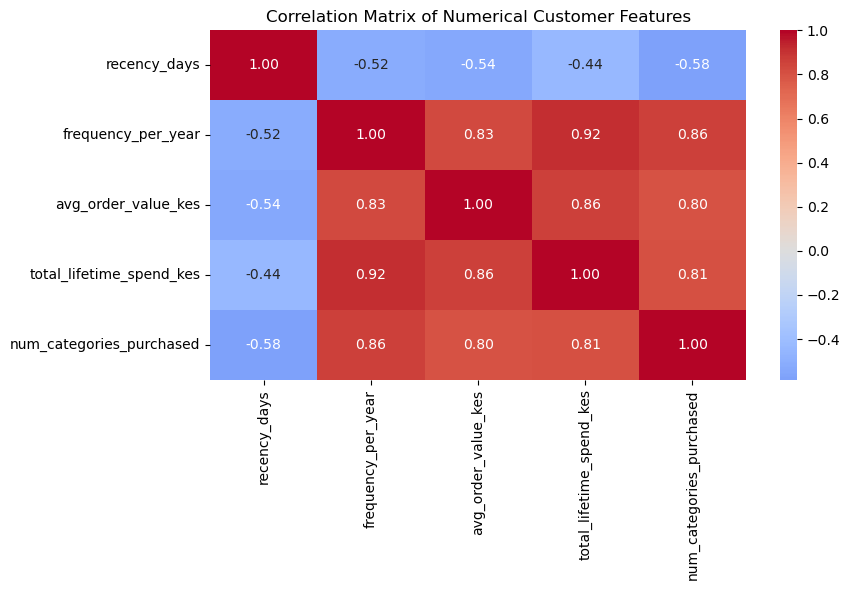

In [105]:
plt.figure(figsize=(9, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numerical Customer Features")
plt.tight_layout()
plt.show()

**Insight:** The correlation analysis shows strong positive relationships among several purchasing-behavior variables. `frequency_per_year` and `total_lifetime_spend_kes` have the strongest correlation at **0.92**, indicating that customers who purchase more frequently also tend to accumulate higher lifetime spending. `frequency_per_year` is also strongly correlated with `num_categories_purchased` (**0.86**) and `avg_order_value_kes` (**0.83**).

`avg_order_value_kes` is strongly correlated with `total_lifetime_spend_kes` (**0.86**), while `total_lifetime_spend_kes` and `num_categories_purchased` have a correlation of **0.81**. These strong correlations indicate that some features contain overlapping information and could potentially double-count purchasing intensity in the Euclidean distance used by K-Means.

In contrast, `recency_days` has moderate negative relationships with the other behavioral variables, ranging from approximately **-0.44 to -0.58**. This suggests that customers who purchased more recently generally tend to purchase more frequently, spend more, and buy across more categories.

Because several candidate clustering features are highly correlated, feature redundancy should be considered before the final clustering feature set is selected rather than automatically including all numerical variables.

### 1.11 Duplicate Record Check

Duplicate observations are checked to ensure that repeated customer records do not unintentionally receive additional weight during clustering.

In [106]:
# Check for completely duplicated rows
duplicate_rows = df.duplicated().sum()

# Check whether customer identifiers are unique
duplicate_ids = df["customer_id"].duplicated().sum()

print("Completely duplicated rows:", duplicate_rows)
print("Duplicated customer IDs:", duplicate_ids)

Completely duplicated rows: 0
Duplicated customer IDs: 0


**Insight:** No completely duplicated rows or duplicated `customer_id` values were found. Therefore, each of the 750 observations represents a unique customer, and no records need to be removed because of duplication.

### 1.12 EDA Summary

The dataset contains **750 unique customers and 7 original variables**. `customer_id` was identified as an identifier and excluded from all descriptive statistics, correlations, visualizations, and future clustering calculations. `preferred_device` is categorical and will be reserved for post-hoc cluster profiling rather than included directly in the K-Means distance calculation.

Five numerical behavioral variables were investigated: `recency_days`, `frequency_per_year`, `avg_order_value_kes`, `total_lifetime_spend_kes`, and `num_categories_purchased`. Their distributions show substantial differences in customer behavior, including customers with different levels of recency, purchasing frequency, transaction value, lifetime spending, and category breadth.

Missingness occurs only in `avg_order_value_kes`, where **26 of 750 observations (3.47%)** are missing. The affected customers still show meaningful purchasing activity, so there is no obvious evidence that the missing values are structurally caused by customers having no purchase activity. The missing values should therefore be handled during preprocessing rather than interpreted as zero.

The boxplots identified a small number of high average-order values and several high lifetime-spending observations. These values remain plausible customer behaviors and may represent commercially meaningful high-value customers, so they were not automatically removed.

The correlation analysis identified substantial redundancy among some purchasing variables. In particular, `frequency_per_year` and `total_lifetime_spend_kes` have a strong positive correlation of **0.92**, while several other purchasing variables have correlations above **0.80**. The final feature-selection stage should therefore consider whether including all of these variables would double-count purchasing intensity in the K-Means distance calculation.

Finally, the dataset contains **no completely duplicated records and no duplicated customer identifiers**, confirming that all 750 rows represent unique customers.

## 2. Feature Selection
### Member 2: Selecting Features

This step decides which features will be used for K-Means clustering.

- Remove the identifier column.
- Keep the categorical variable for profiling after clustering.
- Check the correlation between numeric features.
- Select the numeric features to use for clustering.

The selected features are then passed to Member 3 for preprocessing.

### 2.1 Feature Inclusion and Exclusion

The columns are divided into three groups: removed, kept for profiling, or used for clustering.

- `customer_id` is removed because it only identifies each customer. It does not describe customer behaviour.
- `preferred_device` is kept for profiling after clustering. It is not used in K-Means because converting it into numbers could affect the distance calculations.
- The five numeric behaviour columns are considered for clustering. We will check their correlations to decide which ones to keep.

In [107]:
candidate_features = numeric_features  # the 5 behaviour columns from Section 1

decisions = pd.DataFrame({
    "Column": ["customer_id", "preferred_device", "recency_days", "frequency_per_year",
               "avg_order_value_kes", "total_lifetime_spend_kes", "num_categories_purchased"],
    "Group": ["Identifier", "Categorical", "Numeric", "Numeric",
              "Numeric", "Numeric", "Numeric"],
    "Status at this step": ["Removed", "Held back for profiling", "Candidate", "Candidate",
                            "Candidate", "Candidate", "Candidate"]
})
decisions

,Column,Group,Status at this step
0,customer_id,Identifier,Removed
1,preferred_device,Categorical,Held back for profiling
2,recency_days,Numeric,Candidate
3,frequency_per_year,Numeric,Candidate
4,avg_order_value_kes,Numeric,Candidate
5,total_lifetime_spend_kes,Numeric,Candidate
6,num_categories_purchased,Numeric,Candidate


### 2.2 Correlation Check

K-Means uses distance to group similar customers. If two features are very similar, they may give the same information twice.

- Check the correlation between the candidate features.
- Look for feature pairs with an absolute correlation of **0.80 or higher**.
- Use the results to decide which features should be included in the final clustering.

In [108]:
corr = df[candidate_features].corr()

# Keep each pair once (upper triangle only)
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
pairs = upper.stack().reset_index()
pairs.columns = ["Feature 1", "Feature 2", "Correlation"]
pairs["Abs"] = pairs["Correlation"].abs()

strong_pairs = pairs[pairs["Abs"] >= 0.80].sort_values("Abs", ascending=False)
strong_pairs.round(2)

,Feature 1,Feature 2,Correlation,Abs
5,frequency_per_year,total_lifetime_spend_kes,0.92,0.92
6,frequency_per_year,num_categories_purchased,0.86,0.86
7,avg_order_value_kes,total_lifetime_spend_kes,0.86,0.86
4,frequency_per_year,avg_order_value_kes,0.83,0.83
9,total_lifetime_spend_kes,num_categories_purchased,0.81,0.81


**Insight:** Some of the five features are strongly related to each other.

- `frequency_per_year` and `total_lifetime_spend_kes` have the strongest correlation (0.92).
- `frequency_per_year` is also strongly related to `avg_order_value_kes` (0.83) and `num_categories_purchased` (0.86).
- `recency_days` is different, with moderate negative correlations (-0.44 to -0.58).

Keeping all five features may give too much importance to how much a customer buys, while giving less importance to how recently they purchased. Therefore some highly correlated features may be removed before clustering.

### 2.3 Why Lifetime Spend Repeats Other Features

`total_lifetime_spend_kes` is related to how often a customer buys and how much they spend per order.

We can check this by dividing lifetime spend by:

`frequency_per_year × avg_order_value_kes`

If the result is fairly consistent, it may show the approximate number of years the customer has been active. This means `total_lifetime_spend_kes` may repeat information already provided by the other features.

In [109]:
ratio = df["total_lifetime_spend_kes"] / (df["frequency_per_year"] * df["avg_order_value_kes"])
ratio.describe().round(2)

count    724.00
mean       2.52
std        0.58
min        1.46
25%        2.02
50%        2.53
75%        3.02
max        3.52
dtype: float64

**Insight:** The ratio has a median of **2.53** with most values between **2.02** and **3.02**.

This shows that lifetime spend is closely related to how often customers buy how much they spend per order and how long they have been customers.

Because `total_lifetime_spend_kes` is already related to other features keeping it may repeat information and give too much importance to purchasing behaviour. This is supported by its strong correlation with `frequency_per_year` (0.92).

### 2.4 Final Clustering Features

**Decision:** We remove `total_lifetime_spend_kes` from the clustering features because it is closely related to other features and has the highest correlation (0.92).

We keep it in the dataset so we can use it later to describe how much each customer segment spends.

The final clustering features are:

- `recency_days` – how recently the customer purchased
- `frequency_per_year` – how often the customer purchases
- `avg_order_value_kes` – how much the customer spends per order
- `num_categories_purchased` – how many different categories the customer buys

Some features are still correlated (0.80–0.86) but each measures a different part of customer behaviour. We keep them because removing more features would leave too little information for clustering.

Later we will also test clustering with all five features to see how much the results change.

Clustering features: ['recency_days', 'frequency_per_year', 'avg_order_value_kes', 'num_categories_purchased']
Held back for profiling: ['preferred_device', 'total_lifetime_spend_kes']
Removed entirely: ['customer_id']


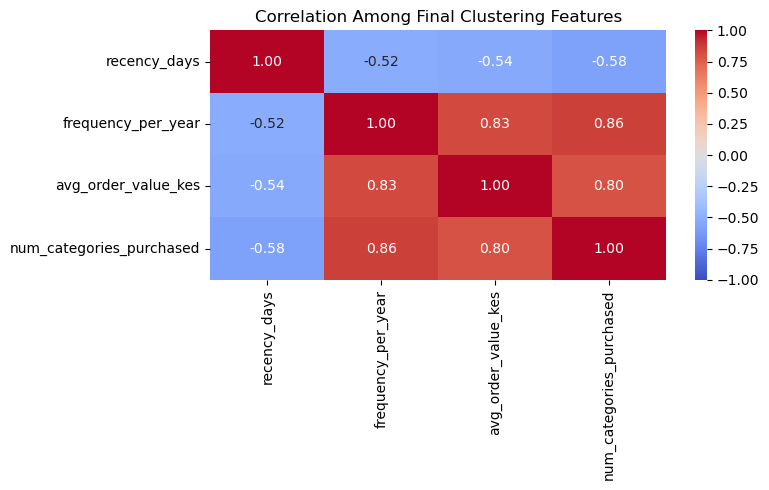

In [110]:
dropped_from_clustering = ["total_lifetime_spend_kes"]
clustering_features = [f for f in candidate_features if f not in dropped_from_clustering]
profiling_features = ["preferred_device", "total_lifetime_spend_kes"]

print("Clustering features:", clustering_features)
print("Held back for profiling:", profiling_features)
print("Removed entirely: ['customer_id']")

plt.figure(figsize=(8, 5))
sns.heatmap(df[clustering_features].corr(), annot=True, fmt=".2f",
            cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Correlation Among Final Clustering Features")
plt.tight_layout()
plt.show()

**Insight:** After removing `total_lifetime_spend_kes` the strongest remaining correlation is between `frequency_per_year` and `num_categories_purchased` (0.86).

The correlation is still high but the two features measure different aspects of customer behaviour. Therefore we keep both and check the effect of this choice later in the robustness test.

### 2.5 Feature Selection Summary

- **Removed:** `customer_id` because it is only an identifier.
- **Kept for profiling:** `preferred_device` and `total_lifetime_spend_kes`. These will help describe the customer groups after clustering.
- **Used for clustering:** `recency_days`, `frequency_per_year`, `avg_order_value_kes` and `num_categories_purchased`.
- **Preprocessing note:** `avg_order_value_kes` has 26 missing values (3.47%). These must be handled before scaling.